# Atlassian Case Study: Improving Sprint Efficiency

## Objective
Analyze simulated Jira-style ticket data to identify bottlenecks in sprint performance, ticket delays, and workload imbalance.

## Business Questions
- Which tickets take the longest to resolve?
- Do reopened tickets increase cycle time?
- Are some assignees overloaded?
- Are some teams slower than others?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 400

df = pd.DataFrame({
    'ticket_id': [f"ATL-{1000+i}" for i in range(n)],
    'created_date': pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 120, n), unit='D'),
    'priority': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.25, 0.5, 0.25]),
    'assignee': np.random.choice(['Alice', 'Bob', 'Charlie', 'David', 'Emma', 'Fatima', 'Grace', 'Henry'], n),
    'team': np.random.choice(['Platform', 'Cloud', 'Security', 'DevOps'], n),
    'story_points': np.random.choice([1, 2, 3, 5, 8, 13], n, p=[0.10, 0.15, 0.25, 0.25, 0.20, 0.05]),
    'reopened_flag': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'ticket_type': np.random.choice(['Bug', 'Task', 'Story'], n, p=[0.3, 0.3, 0.4]),
    'sprint_id': np.random.choice([f"Sprint-{i}" for i in range(1, 9)], n)
})

resolution_days = []
for p, sp, r in zip(df['priority'], df['story_points'], df['reopened_flag']):
    base = np.random.randint(1, 6)
    if p == 'High':
        base += 2
    if sp >= 8:
        base += 3
    if r == 1:
        base += 2
    resolution_days.append(base + np.random.randint(0, 3))

df['resolved_date'] = df['created_date'] + pd.to_timedelta(resolution_days, unit='D')
df['cycle_time_days'] = (df['resolved_date'] - df['created_date']).dt.days
df['delay_flag'] = np.where(df['cycle_time_days'] > 7, 1, 0)
df['month'] = df['created_date'].dt.to_period('M').astype(str)

df.head()

,ticket_id,created_date,priority,assignee,team,story_points,reopened_flag,ticket_type,sprint_id,resolved_date,cycle_time_days,delay_flag,month
0,ATL-1000,2025-04-13,High,Alice,Platform,1,1,Task,Sprint-6,2025-04-21,8,1,2025-04
1,ATL-1001,2025-02-21,Medium,Charlie,Cloud,5,0,Bug,Sprint-8,2025-02-25,4,0,2025-02
2,ATL-1002,2025-04-03,Medium,Emma,DevOps,3,0,Bug,Sprint-6,2025-04-06,3,0,2025-04
3,ATL-1003,2025-01-15,Low,David,Platform,8,0,Story,Sprint-5,2025-01-24,9,1,2025-01
4,ATL-1004,2025-04-17,Medium,Grace,Platform,13,0,Story,Sprint-5,2025-04-22,5,0,2025-04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ticket_id        400 non-null    object        
 1   created_date     400 non-null    datetime64[ns]
 2   priority         400 non-null    object        
 3   assignee         400 non-null    object        
 4   team             400 non-null    object        
 5   story_points     400 non-null    int64         
 6   reopened_flag    400 non-null    int64         
 7   ticket_type      400 non-null    object        
 8   sprint_id        400 non-null    object        
 9   resolved_date    400 non-null    datetime64[ns]
 10  cycle_time_days  400 non-null    int64         
 11  delay_flag       400 non-null    int64         
 12  month            400 non-null    object        
dtypes: datetime64[ns](2), int64(4), object(7)
memory usage: 40.8+ KB


In [4]:
df.describe(include='all')

,ticket_id,created_date,priority,assignee,team,story_points,reopened_flag,ticket_type,sprint_id,resolved_date,cycle_time_days,delay_flag,month
count,400,400,400,400,400,400.000000,400.0000,400,400,400,400.000000,400.000000,400
unique,400,NaN,3,8,4,NaN,NaN,3,8,NaN,NaN,NaN,4
top,ATL-1000,NaN,Medium,Fatima,Platform,NaN,NaN,Story,Sprint-1,NaN,NaN,NaN,2025-03
freq,1,NaN,188,62,106,NaN,NaN,172,61,NaN,NaN,NaN,106
mean,NaN,2025-02-28 20:31:12,NaN,NaN,NaN,4.757500,0.1425,NaN,NaN,2025-03-06 14:20:23.999999744,5.742500,0.227500,NaN
min,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,1.000000,0.0000,NaN,NaN,2025-01-02 00:00:00,1.000000,0.000000,NaN
25%,NaN,2025-01-30 00:00:00,NaN,NaN,NaN,2.000000,0.0000,NaN,NaN,2025-02-05 00:00:00,4.000000,0.000000,NaN
50%,NaN,2025-03-01 00:00:00,NaN,NaN,NaN,5.000000,0.0000,NaN,NaN,2025-03-06 00:00:00,5.500000,0.000000,NaN
75%,NaN,2025-03-31 00:00:00,NaN,NaN,NaN,8.000000,0.0000,NaN,NaN,2025-04-08 00:00:00,7.000000,0.000000,NaN
max,NaN,2025-04-30 00:00:00,NaN,NaN,NaN,13.000000,1.0000,NaN,NaN,2025-05-09 00:00:00,14.000000,1.000000,NaN


## Analysis 1: Average Cycle Time by Priority

In [5]:
avg_cycle_by_priority = df.groupby('priority')['cycle_time_days'].mean().sort_values(ascending=False)
print(avg_cycle_by_priority)

priority
High      7.274336
Medium    5.239362
Low       4.949495
Name: cycle_time_days, dtype: float64


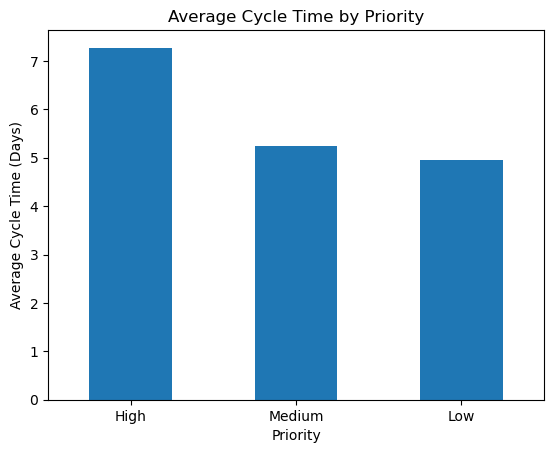

In [6]:
avg_cycle_by_priority.plot(kind='bar')
plt.title('Average Cycle Time by Priority')
plt.xlabel('Priority')
plt.ylabel('Average Cycle Time (Days)')
plt.xticks(rotation=0)
plt.show()

## Analysis 2: Reopened Tickets

In [7]:
reopened_rate = df['reopened_flag'].mean() * 100
print(f"Reopened Ticket Rate: {reopened_rate:.2f}%")

Reopened Ticket Rate: 14.25%


In [8]:
reopened_cycle = df.groupby('reopened_flag')['cycle_time_days'].mean()
print(reopened_cycle)

reopened_flag
0    5.408163
1    7.754386
Name: cycle_time_days, dtype: float64


## Analysis 3: Workload by Assignee

In [9]:
assignee_workload = df['assignee'].value_counts()
print(assignee_workload)

assignee
Fatima     62
Grace      58
Charlie    50
Emma       49
Alice      48
David      48
Henry      43
Bob        42
Name: count, dtype: int64


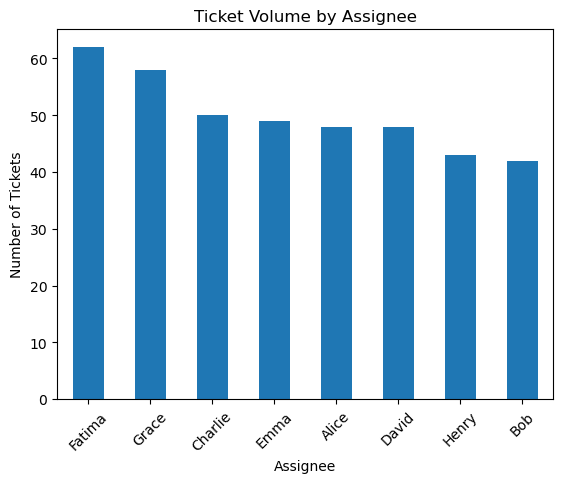

In [10]:
assignee_workload.plot(kind='bar')
plt.title('Ticket Volume by Assignee')
plt.xlabel('Assignee')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.show()

## Analysis 4: Average Cycle Time by Team

In [11]:
team_cycle = df.groupby('team')['cycle_time_days'].mean().sort_values(ascending=False)
print(team_cycle)

team
Platform    5.905660
Cloud       5.817308
Security    5.730769
DevOps      5.465116
Name: cycle_time_days, dtype: float64


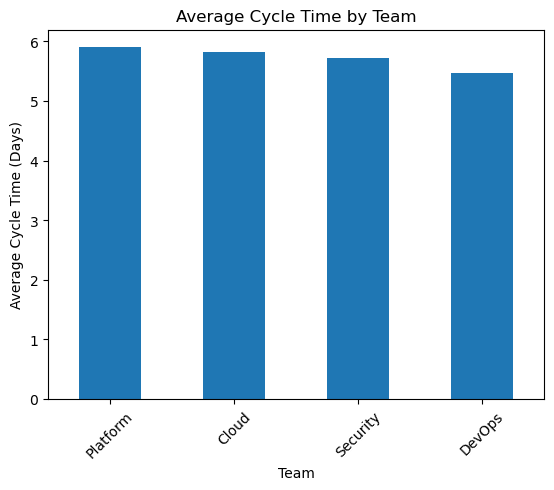

In [12]:
team_cycle.plot(kind='bar')
plt.title('Average Cycle Time by Team')
plt.xlabel('Team')
plt.ylabel('Average Cycle Time (Days)')
plt.xticks(rotation=45)
plt.show()

## Key Insights

1. High-priority tickets had longer average cycle times, suggesting urgent work is often more complex and harder to resolve quickly.

2. Reopened tickets were associated with longer resolution times, indicating that incomplete requirements or QA issues may be contributing to delays.

3. Ticket distribution across assignees was uneven, which may lead to workload imbalance and slower ticket completion for some team members.

4. Some teams showed higher average cycle times than others, suggesting team-specific bottlenecks or process inefficiencies.

## Recommendations

- Use workload-aware ticket assignment to better balance tasks across engineers.
- Improve ticket requirements and QA processes to reduce reopened tickets.
- Monitor team-level cycle times to identify recurring bottlenecks.
- Use historical trends to improve sprint planning and reduce delayed tickets.

In [13]:
df.to_csv("jira_simulated_data.csv", index=False)